In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/milapgohil/play-tennis-dataset-weather-based-classifier/play_tennis_dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/milapgohil/play-tennis-dataset-weather-based-classifier/play_tennis_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6666 entries, 0 to 6665
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Day          6666 non-null   object
 1   Outlook      6267 non-null   object
 2   Temperature  6333 non-null   object
 3   Humidity     6433 non-null   object
 4   Wind         6300 non-null   object
 5   Play         6666 non-null   object
dtypes: object(6)
memory usage: 312.6+ KB


In [3]:
df.shape

(6666, 6)

In [4]:
df.head()
df.isnull().sum()
df.duplicated().sum()

np.int64(4420)

In [5]:
df["Day"] =df["Day"].fillna(df["Day"].mode()[0])
df["Outlook"] =df["Outlook"].fillna(df["Outlook"].mode()[0])
df["Temperature"] =df["Temperature"].fillna(df["Temperature"].mode()[0])
df["Humidity"] =df["Humidity"].fillna(df["Humidity"].mode()[0])
df["Wind"] =df["Wind"].fillna(df["Wind"].mode()[0])
df.isnull().sum()
 
 

Day            0
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play           0
dtype: int64

In [6]:
df = df.drop("Day",axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6666 entries, 0 to 6665
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      6666 non-null   object
 1   Temperature  6666 non-null   object
 2   Humidity     6666 non-null   object
 3   Wind         6666 non-null   object
 4   Play         6666 non-null   object
dtypes: object(5)
memory usage: 260.5+ KB


In [8]:
df.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'], dtype='object')

In [9]:
from sklearn.model_selection import train_test_split
x = df.drop("Play",axis=1)
y = df["Play"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
df = pd.get_dummies(
    df,
    columns=["Outlook","Temperature","Humidity","Wind","Play"],

             dtype = int
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6666 entries, 0 to 6665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Outlook_Overcast  6666 non-null   int64
 1   Outlook_Rainy     6666 non-null   int64
 2   Outlook_Sunny     6666 non-null   int64
 3   Temperature_Cool  6666 non-null   int64
 4   Temperature_Hot   6666 non-null   int64
 5   Temperature_Mild  6666 non-null   int64
 6   Humidity_High     6666 non-null   int64
 7   Humidity_Normal   6666 non-null   int64
 8   Wind_Strong       6666 non-null   int64
 9   Wind_Weak         6666 non-null   int64
 10  Play_No           6666 non-null   int64
 11  Play_Yes          6666 non-null   int64
dtypes: int64(12)
memory usage: 625.1 KB


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6666 entries, 0 to 6665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Outlook_Overcast  6666 non-null   int64
 1   Outlook_Rainy     6666 non-null   int64
 2   Outlook_Sunny     6666 non-null   int64
 3   Temperature_Cool  6666 non-null   int64
 4   Temperature_Hot   6666 non-null   int64
 5   Temperature_Mild  6666 non-null   int64
 6   Humidity_High     6666 non-null   int64
 7   Humidity_Normal   6666 non-null   int64
 8   Wind_Strong       6666 non-null   int64
 9   Wind_Weak         6666 non-null   int64
 10  Play_No           6666 non-null   int64
 11  Play_Yes          6666 non-null   int64
dtypes: int64(12)
memory usage: 625.1 KB


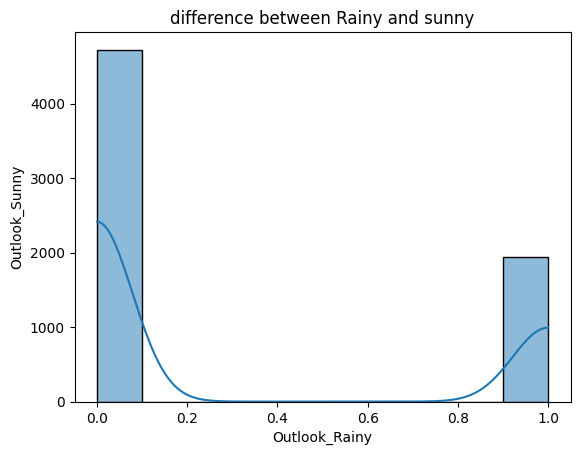

In [12]:
import matplotlib. pyplot as plt
import seaborn as sns
sns.histplot(df["Outlook_Rainy"],bins=10,kde=True)
plt.title("difference between Rainy and sunny")
plt.xlabel("Outlook_Rainy")
plt.ylabel("Outlook_Sunny")
plt.show()